In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("🇮🇳 UPI Fraud Detection Project")
print("Libraries loaded successfully!")

🇮🇳 UPI Fraud Detection Project
Libraries loaded successfully!


In [ ]:
df = pd.read_csv("../data/upi_transactions_2024.csv")

print("✅ Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

✅ Dataset loaded successfully!
Rows: 250000
Columns: 17


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(250000, 17)

Column Names:
['transaction id', 'timestamp', 'transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  ob

In [4]:
print("Fraud Column Check:")

# Fraud column ka exact naam find karna
fraud_cols = [col for col in df.columns if "fraud" in col.lower()]

print("Fraud-related columns:", fraud_cols)

Fraud Column Check:
Fraud-related columns: ['fraud_flag']


In [5]:
print("Fraud Distribution:")
print(df["fraud_flag"].value_counts())

print("\nFraud Percentage:")
print(df["fraud_flag"].value_counts(normalize=True) * 100)

Fraud Distribution:
fraud_flag
0    249520
1       480
Name: count, dtype: int64

Fraud Percentage:
fraud_flag
0    99.808
1     0.192
Name: proportion, dtype: float64


In [6]:
print("Fraud by Transaction Type:")
fraud_by_type = pd.crosstab(
    df["transaction type"],
    df["fraud_flag"]
)

print(fraud_by_type)

Fraud by Transaction Type:
fraud_flag             0    1
transaction type             
Bill Payment       37291   77
P2M                87493  167
P2P               112239  206
Recharge           12497   30


In [7]:
print("\nFraud Rate by Transaction Type (%):")

fraud_rate_type = (
    df.groupby("transaction type")["fraud_flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(fraud_rate_type)


Fraud Rate by Transaction Type (%):
transaction type
Recharge        0.239483
Bill Payment    0.206059
P2M             0.190509
P2P             0.183201
Name: fraud_flag, dtype: float64


In [8]:
print("Amount Statistics:")

print("\nOverall:")
print(df["amount (INR)"].describe())

print("\nGenuine Transactions:")
print(df[df["fraud_flag"] == 0]["amount (INR)"].describe())

print("\nFraud Transactions:")
print(df[df["fraud_flag"] == 1]["amount (INR)"].describe())

Amount Statistics:

Overall:
count    250000.000000
mean       1311.756036
std        1848.059224
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
max       42099.000000
Name: amount (INR), dtype: float64

Genuine Transactions:
count    249520.000000
mean       1311.395391
std        1847.210565
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
max       42099.000000
Name: amount (INR), dtype: float64

Fraud Transactions:
count      480.000000
mean      1499.231250
std       2240.707939
min         28.000000
25%        260.000000
50%        618.500000
75%       1673.500000
max      17718.000000
Name: amount (INR), dtype: float64


In [9]:
print("Average Transaction Amount:")

print("\nGenuine:",
      df[df["fraud_flag"] == 0]["amount (INR)"].mean())

print("Fraud:",
      df[df["fraud_flag"] == 1]["amount (INR)"].mean())

Average Transaction Amount:

Genuine: 1311.39539115101
Fraud: 1499.23125


In [10]:
print("Fraud by Hour:")

fraud_by_hour = (
    df.groupby("hour_of_day")["fraud_flag"]
    .agg(["sum", "count"])
)

fraud_by_hour["fraud_rate_%"] = (
    fraud_by_hour["sum"] / fraud_by_hour["count"] * 100
)

print(fraud_by_hour)

Fraud by Hour:
             sum  count  fraud_rate_%
hour_of_day                          
0              8   3388      0.236128
1              6   2244      0.267380
2              3   1685      0.178042
3              4   1314      0.304414
4              1   1247      0.080192
5              1   1742      0.057405
6              5   3501      0.142816
7             13   5630      0.230906
8             18   8349      0.215595
9             20  10450      0.191388
10            20  13904      0.143843
11            27  16328      0.165360
12            30  17516      0.171272
13            25  15038      0.166246
14            21  11472      0.183054
15            32  12624      0.253485
16            31  13992      0.221555
17            37  18340      0.201745
18            31  20064      0.154506
19            43  21232      0.202524
20            37  18506      0.199935
21            35  16253      0.215345
22            23   9364      0.245622
23             9   5817      0.1547

In [11]:
print("\nTop 5 Hours by Fraud Rate:")

print(
    fraud_by_hour
    .sort_values("fraud_rate_%", ascending=False)
    .head(5)
)


Top 5 Hours by Fraud Rate:
             sum  count  fraud_rate_%
hour_of_day                          
3              4   1314      0.304414
1              6   2244      0.267380
15            32  12624      0.253485
22            23   9364      0.245622
0              8   3388      0.236128


In [12]:
print("Fraud by Device Type:")

device_analysis = (
    df.groupby("device_type")["fraud_flag"]
    .agg(["sum", "count"])
)

device_analysis["fraud_rate_%"] = (
    device_analysis["sum"] / device_analysis["count"] * 100
)

print(device_analysis.sort_values("fraud_rate_%", ascending=False))

Fraud by Device Type:
             sum   count  fraud_rate_%
device_type                           
Web           26   12610      0.206186
Android      364  187777      0.193847
iOS           90   49613      0.181404


In [13]:
print("\nFraud by Network Type:")

network_analysis = (
    df.groupby("network_type")["fraud_flag"]
    .agg(["sum", "count"])
)

network_analysis["fraud_rate_%"] = (
    network_analysis["sum"] / network_analysis["count"] * 100
)

print(network_analysis.sort_values("fraud_rate_%", ascending=False))


Fraud by Network Type:
              sum   count  fraud_rate_%
network_type                           
WiFi           59   25134      0.234742
3G             24   12471      0.192446
4G            282  149813      0.188235
5G            115   62582      0.183759


In [14]:
print("Fraud by Sender State:")

state_analysis = (
    df.groupby("sender_state")["fraud_flag"]
    .agg(["sum", "count"])
)

state_analysis["fraud_rate_%"] = (
    state_analysis["sum"] / state_analysis["count"] * 100
)

print(
    state_analysis
    .sort_values("fraud_rate_%", ascending=False)
)

Fraud by Sender State:
                sum  count  fraud_rate_%
sender_state                            
Karnataka        69  29756      0.231886
Rajasthan        46  19981      0.230219
Gujarat          43  20061      0.214346
Delhi            50  24870      0.201045
Maharashtra      71  37427      0.189703
West Bengal      35  19972      0.175245
Andhra Pradesh   35  20006      0.174948
Telangana        39  22435      0.173836
Uttar Pradesh    52  30125      0.172614
Tamil Nadu       40  25367      0.157685


In [15]:
print("\nTop 10 States by Fraud Rate:")

print(
    state_analysis
    .sort_values("fraud_rate_%", ascending=False)
    .head(10)
)


Top 10 States by Fraud Rate:
                sum  count  fraud_rate_%
sender_state                            
Karnataka        69  29756      0.231886
Rajasthan        46  19981      0.230219
Gujarat          43  20061      0.214346
Delhi            50  24870      0.201045
Maharashtra      71  37427      0.189703
West Bengal      35  19972      0.175245
Andhra Pradesh   35  20006      0.174948
Telangana        39  22435      0.173836
Uttar Pradesh    52  30125      0.172614
Tamil Nadu       40  25367      0.157685


In [16]:
print("Fraud by Merchant Category:")

merchant_analysis = (
    df.groupby("merchant_category")["fraud_flag"]
    .agg(["sum", "count"])
)

merchant_analysis["fraud_rate_%"] = (
    merchant_analysis["sum"] / merchant_analysis["count"] * 100
)

print(
    merchant_analysis
    .sort_values("fraud_rate_%", ascending=False)
)

Fraud by Merchant Category:
                   sum  count  fraud_rate_%
merchant_category                          
Transport           43  20105      0.213877
Education           16   7598      0.210582
Shopping            62  29872      0.207552
Other               50  24828      0.201386
Entertainment       40  20103      0.198975
Food                73  37464      0.194854
Fuel                48  25063      0.191517
Grocery             94  49966      0.188128
Healthcare          21  12663      0.165837
Utilities           33  22338      0.147730


In [17]:
print("\nTop 10 Merchant Categories by Fraud Rate:")

print(
    merchant_analysis
    .sort_values("fraud_rate_%", ascending=False)
    .head(10)
)


Top 10 Merchant Categories by Fraud Rate:
                   sum  count  fraud_rate_%
merchant_category                          
Transport           43  20105      0.213877
Education           16   7598      0.210582
Shopping            62  29872      0.207552
Other               50  24828      0.201386
Entertainment       40  20103      0.198975
Food                73  37464      0.194854
Fuel                48  25063      0.191517
Grocery             94  49966      0.188128
Healthcare          21  12663      0.165837
Utilities           33  22338      0.147730


In [18]:
# Transaction ID prediction ke liye useful nahi hai
df_model = df.drop(columns=["transaction id", "timestamp"])

print("New Dataset Shape:")
print(df_model.shape)

New Dataset Shape:
(250000, 15)


In [19]:
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
['transaction type', 'merchant_category', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']


In [20]:
numerical_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Target ko numerical features se remove karna hai
numerical_cols.remove("fraud_flag")

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
['amount (INR)', 'hour_of_day', 'is_weekend']


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features aur target
X = df_model.drop(columns=["fraud_flag"])
y = df_model["fraud_flag"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nFraud in Training Data:")
print(y_train.value_counts())

print("\nFraud in Testing Data:")
print(y_test.value_counts())

Training Data: (200000, 14)
Testing Data: (50000, 14)

Fraud in Training Data:
fraud_flag
0    199616
1       384
Name: count, dtype: int64

Fraud in Testing Data:
fraud_flag
0    49904
1       96
Name: count, dtype: int64


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing setup
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

# Training aur testing data transform karna
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded Training Shape:", X_train_encoded.shape)
print("Encoded Testing Shape:", X_test_encoded.shape)

Encoded Training Shape: (200000, 69)
Encoded Testing Shape: (50000, 69)


In [23]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Model Training
rf_model.fit(X_train_encoded, y_train)

print("Random Forest Model Training Completed!")

Random Forest Model Training Completed!


In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Test data par prediction
y_pred = rf_model.predict(X_test_encoded)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.99808

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49904
           1       0.00      0.00      0.00        96

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000


Confusion Matrix:
[[49904     0]
 [   96     0]]


In [25]:
# Fraud probability
y_prob = rf_model.predict_proba(X_test_encoded)[:, 1]

print("Fraud Probability Statistics:")
print(pd.Series(y_prob).describe())

print("\nHighest Fraud Probabilities:")
print(
    pd.Series(y_prob)
    .sort_values(ascending=False)
    .head(20)
)

Fraud Probability Statistics:
count    50000.000000
mean         0.002112
std          0.006209
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.240000
dtype: float64

Highest Fraud Probabilities:
26572    0.24
32373    0.18
5399     0.13
15325    0.12
9589     0.12
48811    0.12
2467     0.11
34387    0.11
38040    0.10
42336    0.10
20309    0.10
2083     0.10
7422     0.10
7971     0.09
16227    0.09
44129    0.09
1470     0.09
12420    0.08
7421     0.08
11007    0.08
dtype: float64


In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]

print("Threshold Performance:\n")

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test, y_pred_threshold, zero_division=0
    )
    
    recall = recall_score(
        y_test, y_pred_threshold, zero_division=0
    )
    
    f1 = f1_score(
        y_test, y_pred_threshold, zero_division=0
    )

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 30)

Threshold Performance:

Threshold: 0.05
Precision: 0.0082
Recall:    0.0104
F1 Score:  0.0092
------------------------------
Threshold: 0.08
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
------------------------------
Threshold: 0.1
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
------------------------------
Threshold: 0.12
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
------------------------------
Threshold: 0.15
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
------------------------------
Threshold: 0.2
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
------------------------------


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=2,
    class_weight={0: 1, 1: 20},
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train_encoded, y_train)

print("Improved Random Forest Training Completed!")

Improved Random Forest Training Completed!


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_balanced = rf_balanced.predict(X_test_encoded)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_balanced,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49904
           1       0.00      0.00      0.00        96

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000


Confusion Matrix:
[[49904     0]
 [   96     0]]


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_model = LogisticRegression(
    class_weight={0: 1, 1: 50},
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_encoded, y_train)

print("Logistic Regression Training Completed!")

Logistic Regression Training Completed!


In [30]:
y_pred_lr = lr_model.predict(X_test_encoded)

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49904
           1       0.00      0.00      0.00        96

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000


Confusion Matrix:
[[49901     3]
 [   96     0]]


In [31]:
# Create a simple rule-based fraud risk score

df_risk = df.copy()

df_risk["risk_score"] = 0

# High amount transaction
df_risk.loc[df_risk["amount (INR)"] > 5000, "risk_score"] += 2

# Late night transaction
df_risk.loc[df_risk["hour_of_day"].isin([0, 1, 2, 3, 4, 23]), "risk_score"] += 2

# Web device
df_risk.loc[df_risk["device_type"] == "Web", "risk_score"] += 1

# WiFi network
df_risk.loc[df_risk["network_type"] == "WiFi", "risk_score"] += 1

# Weekend transaction
df_risk.loc[df_risk["is_weekend"] == 1, "risk_score"] += 1

print(df_risk[["amount (INR)", "hour_of_day", 
                "device_type", "network_type", 
                "is_weekend", "fraud_flag", "risk_score"]].head(10))

   amount (INR)  hour_of_day device_type network_type  is_weekend  fraud_flag  \
0           868           15     Android           4G           0           0   
1          1011            6         iOS           4G           0           0   
2           477           13     Android           4G           0           0   
3          2784           10     Android           5G           1           0   
4           990           19         iOS         WiFi           0           0   
5            91           22     Android           3G           0           0   
6           314           10     Android           4G           0           0   
7           264           18     Android           5G           1           0   
8           887            9     Android           4G           0           0   
9          3260           15     Android           4G           0           0   

   risk_score  
0           0  
1           0  
2           0  
3           1  
4           1  
5           

In [32]:
print("\nFraud Rate by Risk Score:")
print(
    df_risk.groupby("risk_score")["fraud_flag"]
    .agg(["count", "sum", "mean"])
)


Fraud Rate by Risk Score:
             count  sum      mean
risk_score                       
0           136767  242  0.001769
1            77218  154  0.001994
2            25109   54  0.002151
3             9046   27  0.002985
4             1523    2  0.001313
5              305    1  0.003279
6               32    0  0.000000


In [33]:
# Fraud probability from Logistic Regression
lr_prob = lr_model.predict_proba(X_test_encoded)[:, 1]

# Convert probability into percentage
lr_prob_percent = lr_prob * 100

print("Fraud Probability Statistics:")
print(pd.Series(lr_prob_percent).describe())

Fraud Probability Statistics:
count    50000.000000
mean         8.650154
std          3.343972
min          1.618858
25%          6.272618
50%          8.113977
75%         10.383428
max         54.246415
dtype: float64


In [34]:
# Create final hybrid score for test data

test_result = X_test.copy()
test_result = test_result.reset_index(drop=True)

test_result["actual_fraud"] = y_test.reset_index(drop=True)

test_result["ml_probability"] = lr_prob_percent

# Start with ML probability
test_result["risk_score"] = test_result["ml_probability"]

# Add rule-based risk
test_result.loc[test_result["amount (INR)"] > 5000, "risk_score"] += 10

test_result.loc[
    test_result["hour_of_day"].isin([0, 1, 2, 3, 4, 23]),
    "risk_score"
] += 10

test_result.loc[
    test_result["device_type"] == "Web",
    "risk_score"
] += 5

test_result.loc[
    test_result["network_type"] == "WiFi",
    "risk_score"
] += 5

test_result.loc[
    test_result["is_weekend"] == 1,
    "risk_score"
] += 3

print(test_result[[
    "amount (INR)",
    "hour_of_day",
    "device_type",
    "network_type",
    "ml_probability",
    "risk_score",
    "actual_fraud"
]].head(10))

   amount (INR)  hour_of_day device_type network_type  ml_probability  \
0           244           15     Android           4G        7.840100   
1          4574           16     Android           4G        3.876332   
2           433           18     Android           4G       10.507998   
3          4415           10     Android           4G        8.975964   
4          4459           21         Web         WiFi       16.200456   
5           487           12     Android           5G        6.420100   
6           875            1     Android           4G        5.156416   
7          1986           22     Android           4G        5.759331   
8          8526            0         iOS           4G        6.091080   
9           478           22     Android           5G        8.519078   

   risk_score  actual_fraud  
0   10.840100             0  
1    3.876332             0  
2   13.507998             0  
3    8.975964             0  
4   26.200456             0  
5    6.420100   

In [35]:
def risk_category(score):
    if score >= 20:
        return "High Risk"
    elif score >= 10:
        return "Medium Risk"
    else:
        return "Low Risk"

test_result["risk_category"] = test_result["risk_score"].apply(risk_category)

print(
    test_result["risk_category"].value_counts()
)

print("\nFraud Rate by Risk Category:")
print(
    test_result.groupby("risk_category")["actual_fraud"]
    .agg(["count", "sum", "mean"])
)

risk_category
Low Risk       25248
Medium Risk    20464
High Risk       4288
Name: count, dtype: int64

Fraud Rate by Risk Category:
               count  sum      mean
risk_category                      
High Risk       4288    5  0.001166
Low Risk       25248   52  0.002060
Medium Risk    20464   39  0.001906


In [36]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Use encoded training data
iso_model = IsolationForest(
    n_estimators=150,
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_encoded)

print("Isolation Forest Training Completed!")

Isolation Forest Training Completed!


In [37]:
# Predict anomalies
iso_pred = iso_model.predict(X_test_encoded)

# Isolation Forest:
#  1  = normal
# -1  = anomaly

iso_fraud_pred = (iso_pred == -1).astype(int)

print("Classification Report:")
print(
    classification_report(
        y_test,
        iso_fraud_pred,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, iso_fraud_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49904
           1       0.00      0.00      0.00        96

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000


Confusion Matrix:
[[49811    93]
 [   96     0]]


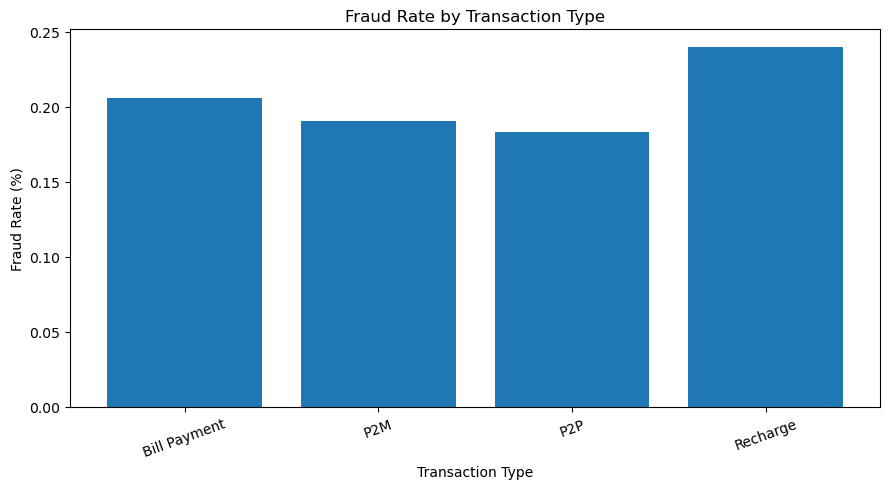

In [38]:
import matplotlib.pyplot as plt

fraud_by_type = (
    df.groupby("transaction type")["fraud_flag"]
    .agg(["count", "sum"])
    .reset_index()
)

fraud_by_type["fraud_rate"] = (
    fraud_by_type["sum"] / fraud_by_type["count"] * 100
)

plt.figure(figsize=(9,5))
plt.bar(
    fraud_by_type["transaction type"],
    fraud_by_type["fraud_rate"]
)

plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

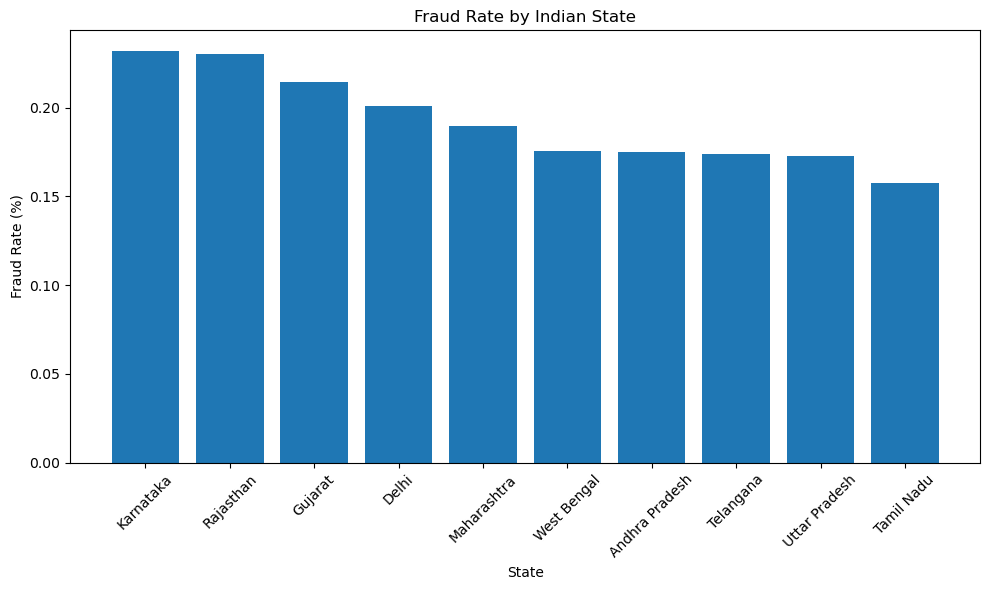

In [39]:
state_fraud = (
    df.groupby("sender_state")["fraud_flag"]
    .agg(["count", "sum"])
    .reset_index()
)

state_fraud["fraud_rate"] = (
    state_fraud["sum"] / state_fraud["count"] * 100
)

state_fraud = state_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.bar(
    state_fraud["sender_state"],
    state_fraud["fraud_rate"]
)

plt.xlabel("State")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Indian State")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

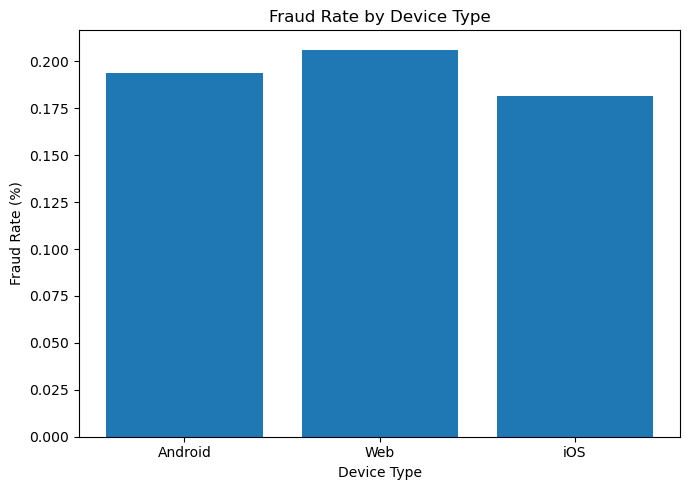

In [40]:
device_fraud = (
    df.groupby("device_type")["fraud_flag"]
    .agg(["count", "sum"])
    .reset_index()
)

device_fraud["fraud_rate"] = (
    device_fraud["sum"] / device_fraud["count"] * 100
)

plt.figure(figsize=(7,5))
plt.bar(
    device_fraud["device_type"],
    device_fraud["fraud_rate"]
)

plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Device Type")
plt.tight_layout()
plt.show()

In [41]:
def predict_transaction_risk(amount, hour, device, network, weekend):

    score = 0

    # Amount risk
    if amount > 5000:
        score += 2

    # Late night risk
    if hour in [0, 1, 2, 3, 4, 23]:
        score += 2

    # Device risk
    if device == "Web":
        score += 1

    # Network risk
    if network == "WiFi":
        score += 1

    # Weekend risk
    if weekend == 1:
        score += 1

    # Risk category
    if score >= 4:
        category = "HIGH RISK"
    elif score >= 2:
        category = "MEDIUM RISK"
    else:
        category = "LOW RISK"

    return score, category


# Example transaction
score, category = predict_transaction_risk(
    amount=8500,
    hour=1,
    device="Web",
    network="WiFi",
    weekend=1
)

print("Transaction Risk Score:", score)
print("Risk Category:", category)

Transaction Risk Score: 7
Risk Category: HIGH RISK


In [42]:
score, category = predict_transaction_risk(
    amount=500,
    hour=14,
    device="Android",
    network="4G",
    weekend=0
)

print("Transaction Risk Score:", score)
print("Risk Category:", category)

Transaction Risk Score: 0
Risk Category: LOW RISK


In [43]:
print("=" * 55)
print("      INDIA DIGITAL TRANSACTION FRAUD ANALYSIS")
print("=" * 55)

print("\n📊 DATASET")
print("Total Transactions :", len(df))
print("Fraud Transactions :", df["fraud_flag"].sum())
print("Genuine Transactions :", (df["fraud_flag"] == 0).sum())

fraud_rate = df["fraud_flag"].mean() * 100
print("Overall Fraud Rate :", round(fraud_rate, 3), "%")

print("\n💰 AMOUNT ANALYSIS")
print("Average Transaction :", 
      round(df["amount (INR)"].mean(), 2))

print("Maximum Transaction :", 
      round(df["amount (INR)"].max(), 2))

print("\n🔍 TOP FRAUD TRANSACTION TYPE")

type_summary = (
    df.groupby("transaction type")["fraud_flag"]
    .agg(["count", "sum"])
)

type_summary["fraud_rate"] = (
    type_summary["sum"] / type_summary["count"] * 100
)

print(
    type_summary.sort_values(
        "fraud_rate",
        ascending=False
    ).head(3)
)

print("\n📍 TOP STATES BY FRAUD RATE")

state_summary = (
    df.groupby("sender_state")["fraud_flag"]
    .agg(["count", "sum"])
)

state_summary["fraud_rate"] = (
    state_summary["sum"] / state_summary["count"] * 100
)

print(
    state_summary.sort_values(
        "fraud_rate",
        ascending=False
    ).head(5)
)

print("\n📱 DEVICE ANALYSIS")

print(
    device_fraud.sort_values(
        "fraud_rate",
        ascending=False
    )
)

print("\n🤖 MODELS TESTED")
print("1. Random Forest")
print("2. Balanced Random Forest")
print("3. Logistic Regression")
print("4. Isolation Forest")

print("\n⚠️ NOTE")
print("Fraud data is highly imbalanced.")
print("Therefore, accuracy alone is not a reliable metric.")

print("\n🚀 FINAL SYSTEM")
print("Rule-Based Transaction Risk Engine")
print("Risk Levels: LOW / MEDIUM / HIGH")

print("=" * 55)

      INDIA DIGITAL TRANSACTION FRAUD ANALYSIS

📊 DATASET
Total Transactions : 250000
Fraud Transactions : 480
Genuine Transactions : 249520
Overall Fraud Rate : 0.192 %

💰 AMOUNT ANALYSIS
Average Transaction : 1311.76
Maximum Transaction : 42099

🔍 TOP FRAUD TRANSACTION TYPE
                  count  sum  fraud_rate
transaction type                        
Recharge          12527   30    0.239483
Bill Payment      37368   77    0.206059
P2M               87660  167    0.190509

📍 TOP STATES BY FRAUD RATE
              count  sum  fraud_rate
sender_state                        
Karnataka     29756   69    0.231886
Rajasthan     19981   46    0.230219
Gujarat       20061   43    0.214346
Delhi         24870   50    0.201045
Maharashtra   37427   71    0.189703

📱 DEVICE ANALYSIS
  device_type   count  sum  fraud_rate
1         Web   12610   26    0.206186
0     Android  187777  364    0.193847
2         iOS   49613   90    0.181404

🤖 MODELS TESTED
1. Random Forest
2. Balanced Random For